# Overview 

This notebook is for catalog-paper sample description figures, not Hα metric analysis.

Planned contents:

- sky distribution of Hα sample
  - Virgo filament / cluster context
- sfr - mstar plot
- histogram comparing halpha vs parent catalog in terms of:
  - distance
  - stellar mass
  - SFR
  - morphology/type
  - environment class
- filters
- 


In [8]:
import os
from matplotlib import pyplot as plt
import numpy as np
from astropy.table import Table
import glob


homedir = os.getenv("HOME")

In [11]:
plotdir = homedir + "/research/Virgo/hapypost/plots/"

# Sky Plot

In [10]:
%run ~/github/Virgo/programs/readtablesv2.py

table directory =  /Users/rfinn/research/Virgo/tables-north/v2/


In [12]:
plt.figure(figsize=(12,6))
plt.subplots_adjust(right=.8)
plot_spines()

haobs_key = "HAPY_HAS_OBS"
plt.plot(v.main['RA'],v.main['DEC'],'k.',alpha=.1,label='Virgo Filament Catalog')
# plot CO sources
flag = v.main[haobs_key] & ~v.main['COflag']
plt.plot(v.main['RA'][flag],v.main['DEC'][flag],'bo',alpha=.5,label=r'$H\alpha$',markersize=8)

flag = v.main['COflag'] & ~v.main[haobs_key]
plt.plot(v.main['RA'][flag],v.main['DEC'][flag],'bo',color='purple',markersize=8,alpha=.7,label=r'$CO, No \ H\alpha$',mec='0.5')
flag = v.main['COflag'] & v.main[haobs_key]
plt.plot(v.main['RA'][flag],v.main['DEC'][flag],'co',markersize=8,alpha=.7,label=r'$CO + H\alpha$',mec='0.5')

plt.legend(bbox_to_anchor=(1.01,1))
# add a rectangle for Blanco DD time, spring 2021
#rect = Rectangle([200,0], 60, 20, fc="none",ec='r',lw=2,label='DECcam targets')
#plt.gca().add_artist(rect)

# add a rectangle for Blanco DD time, spring 2021
#rect = Rectangle([178,-1], 20, 20, fc="none",ec='b',lw=2,label='Virgo Cluster')
#plt.gca().add_artist(rect)

#plt.axis([195,265,-2,30])
# continue with plot
plt.gca().invert_xaxis()
plt.xlabel('RA (deg)',fontsize=20)
plt.ylabel('DEC (deg)',fontsize=20)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
#plt.legend(loc='upper right')
plt.title('Filamentary Structures Surrounding the Virgo Cluster',fontsize=18)
plt.savefig(plotdir+'/halpha_positions.png')
plt.savefig(plotdir+'/halpha_positions.pdf')

NameError: name 'plot_spines' is not defined

<Figure size 1200x600 with 0 Axes>

# SFR-Mstar Sample Overview

In [ ]:
x = v.magphys['logMstar']
y = v.magphys['logSFR']
flag1 = (x > 7)
flag1b = flag1 &  ~v.main['HAobsflag'] & ~v.main['COflag']# valid magphys fit
flag2 = flag1 & v.main['HAobsflag']
flag3 = flag1 & v.main['COflag']
plt.figure(figsize=(8,6))
plt.plot(x[flag1b],y[flag1b],'k.',alpha=.1,label='All VF')
plt.plot(x[flag2],y[flag2],'bs',c=mycolors[0],mec='k',alpha=.7,label='Halpha Sample',markersize=9)
plt.plot(x[flag3],y[flag3],'bo',c=mycolors[1],alpha=.8,label='Primary CO Sample',markersize=5)
plt.xlabel('$\log(M_\star/M_\odot)$',fontsize=22)
plt.ylabel('$\log(SFR/M_\odot/yr)$',fontsize=22)
plt.legend()
#plot_BV_MS(plt.gca())
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlim(6.9,11.1)
plt.savefig(plotdir+'sfr-mstar-halpha.png')
plt.savefig(plotdir+'sfr-mstar-halpha.pdf')

# Filters

In [7]:
# redoing after standardizing filters


filter_dir = homedir+'/research/Halpha_filters/fits_versions/'
hafilters = glob.glob(filter_dir+'*Ha*.fits')
plt.figure(figsize=(10,4))
plt.subplots_adjust(bottom=.15)
xlab = "Wavelength ($\AA$)"
ylab = "Transmission (%)"

# plot halpha filters
hafilters = ['BOK90prime-Ha+4nm.fits',
             'HDI-Ha+4nm.fits',
             'MOS-Ha+4nm.fits',
             'WFC-Ha-197.fits',
             'WFC-Ha-227.fits']

rfilters = ['BOK90prime-BASSr.fits',
             'HDI-SDSSr.fits',
             'HDI-HarrisR.fits',
             'MOS-SDSSr.fits',
             'MOS-HarrisR.fits',
             'WFC-SDSSr-214.fits',
            ]


plt.subplot(1,2,1)
for i,f in enumerate(hafilters):
    tab = Table.read(os.path.join(filter_dir,f))
    plt.plot(tab['wavelength'],tab['transmission'],label=os.path.basename(f).replace('.fits','').replace('BOK',''))
    #print(halabels[i],f"{integrate_filter(wav,T):.2f}")
plt.xlabel(xlab,fontsize=14)
plt.ylabel(ylab,fontsize=14)
plt.title("H-alpha Filters")
plt.xlim(6450,6800)
#plt.ylim(-5,102)
plt.legend(loc='lower right',fontsize=10)


plt.subplot(1,2,2)
# plot halpha filters
for i,f in enumerate(rfilters):
    tab = Table.read(os.path.join(filter_dir,f))
    plt.plot(tab['wavelength'],tab['transmission'],label=os.path.basename(f).replace('.fits','').replace('BOK',''))
    #print(rlabels[i],f"{integrate_filter(wav,T):.2f}")
plt.legend(loc='lower right',fontsize=10)
plt.xlabel(xlab,fontsize=14)
#plt.ylabel(ylab,fontsize=16)
plt.xlim(5000,8750)
plt.ylim(-5,102)
plt.title("Broad-band Filters")

# plot wavelength of halpha
lambda0 = 6563
vr_virgo = 2000
#plt.axvline(x=6625)
plt.savefig(homedir+'/research/Virgo/plots/halpha/filter_traces_v2.png')
plt.savefig(homedir+'/research/Virgo/plots/halpha/filter_traces_v2.pdf')


NameError: name 'glob' is not defined

Running on Rose's computer
tabledir =  /Users/rfinn/research/Virgo/tables-north/v2/


/Users/rfinn/github/havirgo/python/ha-paper1.py:53: RuntimeWarning: invalid value encountered in divide
  snr_flag = np.abs(self.halpha['HF_TOT']/self.halpha['HF_TOT_ERR']) > 3


mean(med) diff b/w R and Halpha PSF = 0.03(0.03) +/- 0.19
H FWHM - R FWHM = 0.03 +/- 0.19


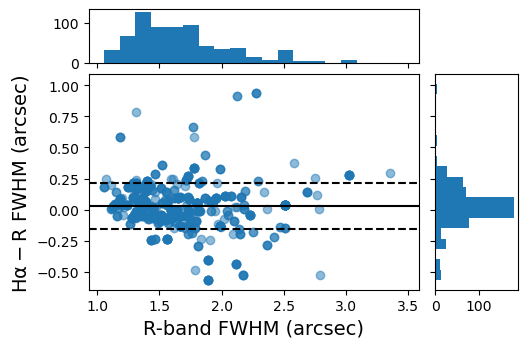

In [6]:
%run ~/github/havirgo/python/ha-paper1.py
h.plot_fwhm_r_h()